# GSGP-NN: Test Suite & Fair Comparison

This notebook:
1. **Executes all unit tests** using `pytest`.
2. **Compares two approaches** on the Diabetes dataset with identical config:
   - `GSGPNNRegressor` (sklearn interface — GP + neural network)
   - `SimpleNN` (standard MLP baseline)

## 1. Execute Project Tests

In [1]:
import sys, os, pytest

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("Running pytest on the 'tests' directory...")
exit_code = pytest.main(["-v", "../tests"])
print(f"Pytest finished with exit code: {exit_code} (0 means all tests passed)")

collected 122 items

../tests/test_dataset.py::TestRegressionDataset::test_load_nonexistent_raises PASSED [  0%]
../tests/test_dataset.py::TestRegressionDataset::test_train_test_split_sizes PASSED [  1%]
../tests/test_dataset.py::TestRegressionDataset::test_num_features PASSED [  2%]
../tests/test_dataset.py::TestRegressionDataset::test_num_train_patterns PASSED [  3%]
../tests/test_dataset.py::TestRegressionDataset::test_y_mean_stored PASSED [  4%]
../tests/test_dataset.py::TestRegressionDataset::test_y_std_stored PASSED [  4%]
../tests/test_dataset.py::TestRegressionDataset::test_get_tensors_shapes PASSED [  5%]
../tests/test_dataset.py::TestRegressionDataset::test_get_tensors_device PASSED [  6%]
../tests/test_dataset.py::TestRegressionDataset::test_get_tensors_dtype PASSED [  7%]
../tests/test_dataset.py::TestRegressionDataset::test_get_tensors_reproducible PASSED [  8%]
../tests/test_estimator.py::TestGPNodeHelpers::test_to_sympy_terminal_variable PASSED [  9%]
../tests/test_estim

## 2. Shared Configuration & Data

Both models share the same hyperparameters so the comparison is fair.

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from src.utils.device import get_device

# ── Dataset ─────────────────────────────────────────────────────────
X, y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test : {X_test.shape[0]} samples")

# ── Device ──────────────────────────────────────────────────────────
device = get_device()

# ── Shared hyperparameters ─────────────────────────────────────────
NUM_NODES = 10          # N — number of GP semantic nodes
NUM_LAYERS = 3          # K — number of GSGP-NN layers
POP_SIZE = 40           # GP population size
LR = 0.01               # learning rate
EPOCHS = 200            # max epochs
ES_PATIENCE = 20        # early stopping patience
ES_WARMUP = 10          # early stopping warm-up
RANDOM_STATE = 42       # reproducibility seed

# ── Scaled tensors (for SimpleNN) ──────────────────────────────────
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_test_s = scaler_X.transform(X_test)
y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_s = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

X_train_t = torch.tensor(X_train_s, dtype=torch.float32, device=device)
X_test_t  = torch.tensor(X_test_s,  dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train_s, dtype=torch.float32, device=device)
y_test_t  = torch.tensor(y_test_s,  dtype=torch.float32, device=device)

Train: 353 samples, 10 features
Test : 89 samples
[Device] Using GPU: NVIDIA GeForce GTX 1650
[Device] VRAM: 4.3 GB
[Device] CUDA Capability: 7.5


---
## 3. GSGPNNRegressor (scikit-learn Interface)

Wraps the full GP generation + semantic evaluation + neural network training in a single `fit`/`predict` call.

In [3]:
from src.models.gsgp_nn_estimator import GSGPNNRegressor, model, complexity

gsgp_est = GSGPNNRegressor(
    num_nodes=NUM_NODES,
    num_layers=NUM_LAYERS,
    population_size=POP_SIZE,
    learning_rate=LR,
    epochs=EPOCHS,
    early_stopping_patience=ES_PATIENCE,
    early_stopping_warmup=ES_WARMUP,
    verbose=True,
    random_state=RANDOM_STATE,
)

# GSGPNNRegressor scales X and y internally — pass raw data
print("Training GSGPNNRegressor...")
gsgp_est.fit(X_train, y_train)

y_pred_gsgp = gsgp_est.predict(X_test)
mse_gsgp = mean_squared_error(y_test, y_pred_gsgp)
r2_gsgp = r2_score(y_test, y_pred_gsgp)
params_gsgp = gsgp_est.model_.count_parameters()

print(f"\nGSGPNNRegressor  |  MSE: {mse_gsgp:.2f}  |  R²: {r2_gsgp:.4f}  |  Params: {params_gsgp:,}")
print(f"SymPy expression : {model(gsgp_est)}")
print(f"Complexity       : {complexity(gsgp_est)} nodes")

Training GSGPNNRegressor...
[Device] Using GPU: NVIDIA GeForce GTX 1650
[Device] VRAM: 4.3 GB
[Device] CUDA Capability: 7.5
[GP] Generating populations of size 40...
[GP] Evaluating initial population semantics...
[GP] Evaluating auxiliary population semantics...
[GP] Semantic tensors ready — initial: torch.Size([10, 353]), parent: torch.Size([10, 353]), routes: 3 layers × (N=10, M=353)
Epoch    1: Loss = 1.027880   [0.031s]
Epoch    2: Loss = 1.010107   [0.026s]
Epoch    3: Loss = 0.993471   [0.031s]
Epoch    4: Loss = 0.977682   [0.027s]
Epoch    5: Loss = 0.962105   [0.021s]
Epoch    6: Loss = 0.946256   [0.024s]
Epoch    7: Loss = 0.929835   [0.024s]
Epoch    8: Loss = 0.912618   [0.020s]
Epoch    9: Loss = 0.894447   [0.022s]
Epoch   10: Loss = 0.875211   [0.020s]
Epoch   11: Loss = 0.854752   [0.020s]
Epoch   12: Loss = 0.833467   [0.019s]
Epoch   13: Loss = 0.811925   [0.020s]
Epoch   14: Loss = 0.790444   [0.020s]
Epoch   15: Loss = 0.769726   [0.019s]
Epoch   16: Loss = 0.7512

---
## 4. SimpleNN (MLP Baseline)

Standard feed-forward network with approximately the same number of parameters as GSGP-NN.

In [4]:
import torch.nn as nn
from src.training.early_stopping import EarlyStopping
from src.utils.seed import set_seed


class SimpleNN(nn.Module):
    """MLP with comparable capacity to GSGP-NN(N=10, K=3 → 401 params)."""
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 20),
            nn.ReLU(),
            nn.Linear(20, 10),
            nn.ReLU(),
            nn.Linear(10, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(1)

    def count_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


set_seed(RANDOM_STATE)
nn_model = SimpleNN(input_dim=X_train_s.shape[1]).to(device)
params_nn = nn_model.count_parameters()

optimizer = torch.optim.Adam(nn_model.parameters(), lr=LR)
es = EarlyStopping(patience=ES_PATIENCE, min_delta=1e-5, warmup_epochs=ES_WARMUP)

loss_history_nn = []
nn_model.train()

for epoch in range(1, EPOCHS + 1):
    optimizer.zero_grad()
    y_pred = nn_model(X_train_t)
    loss = nn.functional.mse_loss(y_pred, y_train_t)
    loss.backward()
    optimizer.step()

    loss_val = loss.item()
    loss_history_nn.append(loss_val)

    if epoch <= 10 or epoch % 25 == 0:
        print(f"Epoch {epoch:3d}  |  Loss = {loss_val:.6f}")

    if es(loss_val):
        print(f"[EarlyStopping] Stopped at epoch {epoch}")
        break

print(f"\nSimpleNN final loss: {loss_history_nn[-1]:.6f}")

Epoch   1  |  Loss = 1.020567
Epoch   2  |  Loss = 0.979426
Epoch   3  |  Loss = 0.942502
Epoch   4  |  Loss = 0.907395
Epoch   5  |  Loss = 0.871263
Epoch   6  |  Loss = 0.832861
Epoch   7  |  Loss = 0.792702
Epoch   8  |  Loss = 0.751987
Epoch   9  |  Loss = 0.711940
Epoch  10  |  Loss = 0.673616
Epoch  25  |  Loss = 0.464190
Epoch  50  |  Loss = 0.392783
Epoch  75  |  Loss = 0.333656
Epoch 100  |  Loss = 0.259996
Epoch 125  |  Loss = 0.202604
Epoch 150  |  Loss = 0.158655
Epoch 175  |  Loss = 0.135267
Epoch 200  |  Loss = 0.117063

SimpleNN final loss: 0.117063


In [5]:
# Evaluate SimpleNN on test set
nn_model.eval()
with torch.no_grad():
    y_pred_nn_scaled = nn_model(X_test_t).cpu().numpy()
y_pred_nn = scaler_y.inverse_transform(y_pred_nn_scaled.reshape(-1, 1)).flatten()

mse_nn = mean_squared_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)

print(f"SimpleNN           |  MSE: {mse_nn:.2f}  |  R²: {r2_nn:.4f}  |  Params: {params_nn:,}")

SimpleNN           |  MSE: 4278.28  |  R²: 0.1925  |  Params: 441


---
## 5. Final Comparison

Both models trained with **identical** learning rate, max epochs, early stopping policy, and random seed.

In [6]:
print("=" * 72)
print("FAIR COMPARISON  —  Diabetes dataset")
print("=" * 72)
print(f"{'':<30} {'GSGPNNRegressor':<20} {'SimpleNN':<20}")
print(f"{'-'*30} {'-'*20} {'-'*20}")
print(f"{'Test MSE':<30} {mse_gsgp:<20.2f} {mse_nn:<20.2f}")
print(f"{'Test R²':<30} {r2_gsgp:<20.4f} {r2_nn:<20.4f}")
print(f"{'Trainable parameters':<30} {params_gsgp:<20,} {params_nn:<20,}")
print(f"{'Epochs trained':<30} {gsgp_est.history_['epochs_trained']:<20} {len(loss_history_nn):<20}")
print(f"{'Learning rate':<30} {LR:<20} {LR:<20}")
print(f"{'Early stopping patience':<30} {ES_PATIENCE:<20} {ES_PATIENCE:<20}")
print(f"{'Random seed':<30} {RANDOM_STATE:<20} {RANDOM_STATE:<20}")

print(f"\n--- SRBench ---")
print(f"SymPy expression: {model(gsgp_est)}")
print(f"Complexity      : {complexity(gsgp_est)} nodes")
print(f"{'=' * 72}")

if r2_gsgp > r2_nn:
    print(f"\n✓ GSGPNNRegressor outperforms SimpleNN by {abs(r2_gsgp - r2_nn):.4f} R²")
elif r2_nn > r2_gsgp:
    print(f"\n✗ SimpleNN outperforms GSGPNNRegressor by {abs(r2_nn - r2_gsgp):.4f} R²")
else:
    print("\n— Both models achieved the same R²")

FAIR COMPARISON  —  Diabetes dataset
                               GSGPNNRegressor      SimpleNN            
------------------------------ -------------------- --------------------
Test MSE                       3053.27              4278.28             
Test R²                        0.4237               0.1925              
Trainable parameters           401                  441                 
Epochs trained                 200                  200                 
Learning rate                  0.01                 0.01                
Early stopping patience        20                   20                  
Random seed                    42                   42                  

--- SRBench ---
SymPy expression: ((x9 + x7) - (x9 + x9))
Complexity      : 7 nodes

✓ GSGPNNRegressor outperforms SimpleNN by 0.2312 R²


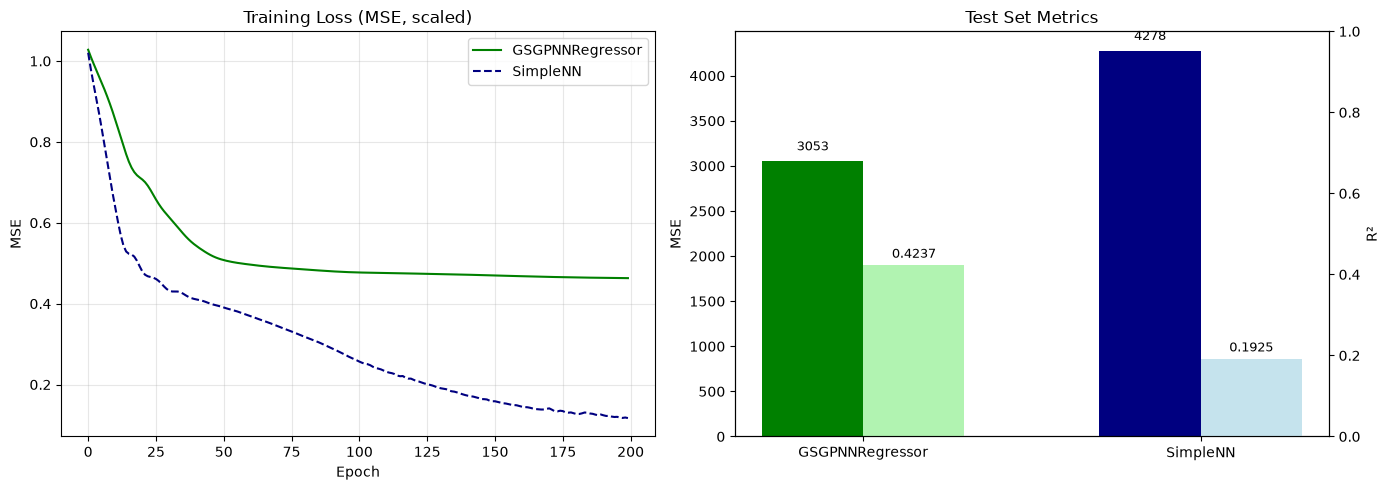

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Loss curves ────────────────────────────────────────────────────
ax = axes[0]
ax.plot(gsgp_est.history_["loss_history"], label="GSGPNNRegressor", color="green", lw=1.5)
ax.plot(loss_history_nn, label="SimpleNN", color="navy", lw=1.5, linestyle="--")
ax.set_title("Training Loss (MSE, scaled)")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")
ax.legend()
ax.grid(True, alpha=0.3)

# ── Bar chart ──────────────────────────────────────────────────────
ax = axes[1]
labels = ['GSGPNNRegressor', 'SimpleNN']
x = np.arange(len(labels))
width = 0.30

bars1 = ax.bar(x - width/2, [mse_gsgp, mse_nn], width,
               label='MSE', color=['green', 'navy'])
ax.set_ylabel('MSE')
ax.set_xticks(x)
ax.set_xticklabels(labels)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(mse_gsgp, mse_nn)*0.02,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=9)

ax2 = ax.twinx()
bars2 = ax2.bar(x + width/2, [r2_gsgp, r2_nn], width,
                label='R²', color=['lightgreen', 'lightblue'], alpha=0.7)
ax2.set_ylabel('R²')
ax2.set_ylim(0, 1)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

ax.set_title("Test Set Metrics")
fig.tight_layout()
plt.show()